# Fourier Transform

# 1. Introduction

#### In this notebook we will look at how we can determine what frequencies are inside this signal. We’ll use the Fourier transform (known as the FFT in NumPy) to analyze both single-tone and multi-tone signals. This will let us connect the time-domain signals we built in Phases 1 and 2 to a new, frequency-domain view that is much closer to what real RF test equipment shows.

# 2. Background and Objectives

## Background
#### In both Phases 1 and 2 we used, $ x(t) = Asin(2ft\pi+ Φ) $ to represent signals as functions of time. This is known as the time-domain view.
#### The Fourier transform provides us with a function that tells us how much of each frequency is present in the signal. 
#### For a continuous signal, the Fourier transform produces a frequency-domain function:
#### $ X(f) = \int_{-\infty}^{\infty} x(t)\, e^{-2\pi f t j}\, dt $
#### A pure sine wave at frequency produces a single spike while a sum of sine waves produces a spectrum with spikes at each component frequency.
#### The magnitude of the Fourier transform shows how strong each frequency is.

## Objectives
#### 1. Plot signals in the time domain.
#### 2. Compute FFTs.
#### 3. Plot frequency spectra.
#### 4. Compare time-domain and frequency-domain views side by side.
#### 5. Analyze single-tone and multi-tone signals.


# 3. Computational Methods

#### The new methods used for this section will be the Fast Fourier Transform (FFT) computation and the Discrete Fourier Transform (DFT) computation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt  

fs = 10000 
duration = 0.05 
t = np.linspace(0, duration, int(fs * duration), endpoint=False) 

def generate_sine(amplitude, frequency, phase, t):
    return amplitude * np.sin(2 * np.pi * frequency * t + phase)
    
def compute_fft(x, fs):

    N = len(x)  # number of samples
    X = np.fft.fft(x) # Preforming the FFT
    freqs = np.fft.fftfreq(N, 1/fs) #Shows the frequencies associated with each sample 

    mask = freqs >= 0  # Only keep non-negative frequencies
    freqs_pos = freqs[mask]
    mag_pos = np.abs(X[mask])   #Calculating the magnitude

    return freqs_pos, mag_pos

def plot_signal(t, x, title="", xlabel="Time (s)", ylabel="Amplitude"):
    plt.figure(figsize=(8, 3))
    plt.plot(t, x)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

def plot_spectrum(freqs, magnitude, title="", xlabel="Frequency (Hz)", ylabel="Magnitude"):
    plt.figure(figsize=(8, 3))
    plt.stem(freqs, magnitude)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# 4. Visualizations and Observations

## 4.1 Single Tone Signal

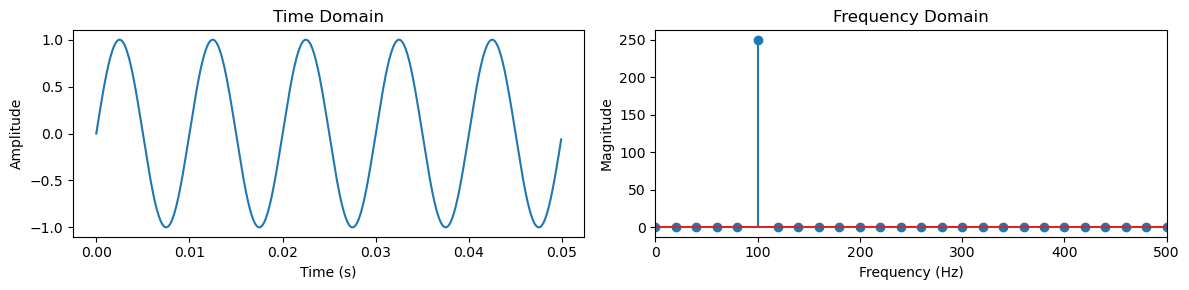

In [11]:
A, f, phase = 1, 100, 0
x = generate_sine(A, f, phase, t)

freqs, mag =compute_fft(x, fs)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].plot(t, x)
axes[0].set_title("Time Domain")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

# Frequency-domain
axes[1].stem(freqs, mag)
axes[1].set_title("Frequency Domain")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude")
axes[1].set_xlim(0, 500)  #focus low frequencies

plt.tight_layout()
plt.show()

### Observations:
#### - The 100 Hz sine wave in the time domain is a smooth simple wave while the frequency domain, the magnitude spectrum shows a single strong peak at 100 Hz.
#### - This shows that a pure sine wave has energy concentrated at one frequency.

## 4.2 Two Tone Signal

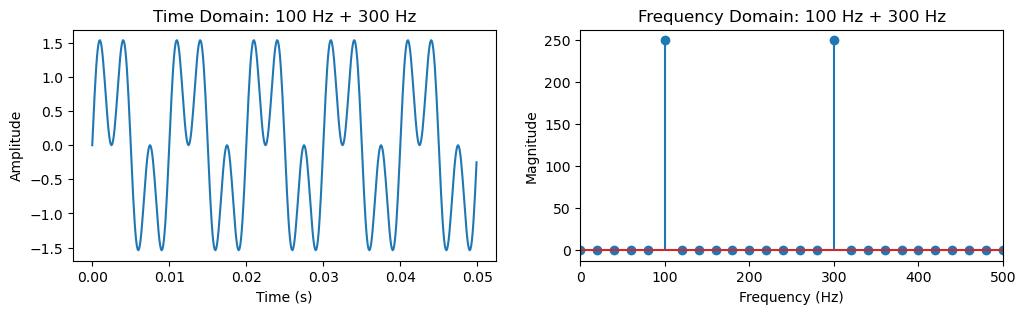

In [12]:
A1, f1, phase1 = 1, 100, 0
A2, f2, phase2 = 1, 300, 0

x1 = generate_sine(A1, f1, phase1, t)
x2 = generate_sine(A2, f2, phase2, t)

x_total = x1 + x2

freqs_sum, mag_sum = compute_fft(x_total, fs)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Time-domain
axes[0].plot(t, x_total)
axes[0].set_title("Time Domain: 100 Hz + 300 Hz")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

# Frequency-domain
axes[1].stem(freqs_sum, mag_sum)
axes[1].set_title("Frequency Domain: 100 Hz + 300 Hz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude")
axes[1].set_xlim(0, 500)  # focus on low frequencies

plt.show()


### Observations:
#### - The added up signals show the same complex graph as in phase 2.
#### - Even though the time-domain graph looks really complex, the frequency-domian graph is much simplier and shows the two peaks at their frequency.

## 4.3 Three Tone Signal

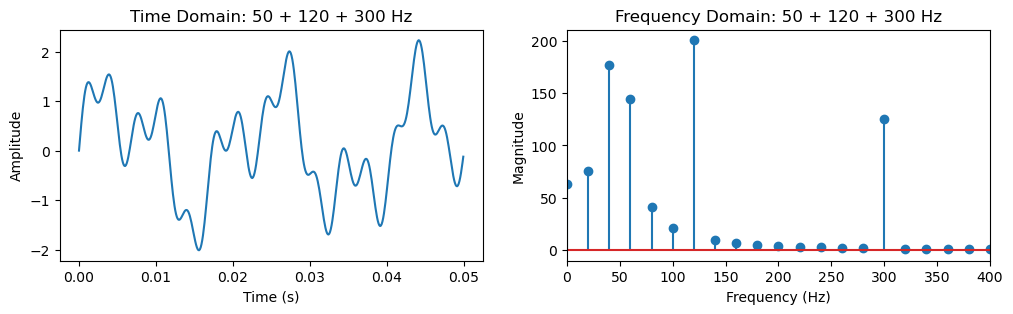

In [13]:
A1, f1, phase1 = 1, 50, 0
A2, f2, phase2 = 0.8, 120, 0
A3, f3, phase3 = 0.5, 300, 0

x1 = generate_sine(A1, f1, phase1, t)
x2 = generate_sine(A2, f2, phase2, t)
x3 = generate_sine(A3, f3, phase3, t)

x_total = x1 + x2 + x3

freqs3, mag3 = compute_fft(x_total, fs)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Time-domain
axes[0].plot(t, x_total)
axes[0].set_title("Time Domain: 50 + 120 + 300 Hz")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

# Frequency-domain
axes[1].stem(freqs3, mag3)
axes[1].set_title("Frequency Domain: 50 + 120 + 300 Hz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude")
axes[1].set_xlim(0, 400)

plt.show()

### Observations:
#### - Very complex on the time-domain and would be very hard to predict what waves created it.
#### - The frequency-domain chart shows clearly the 300 Hz and 120 Hz frequency but is a little harder to know that 50 Hz is the third frequency.

# 5. Conclusions

#### We learned about how:
#### A single sine wave in time corresponds to a specific frequency in the spectrum.
#### When you sum multiple sine waves together you can still decrypt which frequencies are presnt with fourier transform.

# 6. Future Questions

#### How does the length of the time and sampling rate affect the accuracy of the FFT?
#### Can we use the FFT to detect signals that are very weak or affected by another condition?
#### What is noise and how does it affect signals?